In [4]:
pip install bertopic -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.1 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
from bertopic import BERTopic

In [7]:
input_connect_data = pd.read_csv("/content/drive/MyDrive/i_instace_db/dummy_variable_data_public.csv")

In [8]:
input_connect_data.shape

(1268, 52)

In [9]:
input_connect_data = input_connect_data[['incident_number', 'app_id','created_on', 'description',
       'short_description', 'assignment_group', 'category','app_name',
       'resolution_code', 'resolution_update',
       'meta_tags']]

In [10]:
input_connect_data.head()

,incident_number,app_id,created_on,description,short_description,assignment_group,category,app_name,resolution_code,resolution_update,meta_tags
0,INC012569078,E0SV,2024-07-18T16:06:54.000,Fallout Receive-SBC-Start-Trigger-From-ESAP 45...,SO# 215115809 | Customer# WACKER SILICONE MAN...,NTS_E0SV_RVOIP_SUPPORT,Business Application Services,CONNECT,Service/Application Restarted,\r\nMentioned fallout is cleared.\r\nOrder is ...,E0SV 19032
1,INC012555303,E0SV,2024-07-17T00:28:10.000,Description:tpalpe0sva001.verizon.com-NoRespon...,VSAD ID:E0SV;Description:tpalpe0sva001.verizon...,NTS_PS_VZINDIA,Business Application Services,CONNECT,Fixed by Automation,Good to Close,E0SV 19032
2,INC012609983,E0SV,2024-07-24T11:48:21.000,Please clear/complete Check-For-Locations-Disc...,Please clear/complete Check-For-Locations-Disc...,NTS_E0SV_ESAPNET_SUPPORT,Business Application Services,CONNECT,Service/Application Restarted,Fallout cleared and order waiting for router d...,E0SV 19032
3,INC012674241,E0SV,2024-08-03T07:05:20.000,Ticket Automatically Created from OMi ---- \nO...,tdclpe0svd003-DISK SPACE: /apps/opt/postgres/b...,NTS_DBA_OPS_TECHOPS,Business Application Services,CONNECT,Resolved by Problem Management,PIT request raised for extending mountpoint,E0SV 19032
4,INC012655659,E0SV,2024-07-31T14:02:58.000,WO-44165335 showing PC status IPSEC Provisioi...,WO-44165335 showing PC status IPSEC Provisioi...,NTS_E0SV_RVOIP_SUPPORT,Business Application Services,CONNECT,Database Updated/Data Scrub,WO 44165335 is now at WO_WAIT_FOR_IPSEC_INPUT...,E0SV 19032


In [11]:
# Combine the 'description' and 'short_description' columns
input_connect_data['consolidated_description'] = input_connect_data['description'] + ' ' + input_connect_data['short_description']

# Remove any null values
input_connect_data.dropna(subset=['consolidated_description'], inplace=True)

In [12]:
df = input_connect_data.copy()

In [14]:
# !pip install bertopic
# !pip install plotly
# # !pip install scipy
# !pip install scipy==1.11.4
# !pip install pandas
# !pip install sentence_transformers
# !pip install umap-learn

In [15]:
import pandas as pd
import scipy.constants as spc
from scipy.cluster import hierarchy as sch
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic.representation import KeyBERTInspired


class TopicModeling:
    def __init__(self, df, column_name, sentence_transformer_model='google-bert/bert-large-uncased'):

        # "bert-large-multilingual-cased",  "dunzhang/stella_en_1.5B_v"

        """
        Initialize the TopicModeling class with the necessary models and data.
        :param df: DataFrame containing the text data.
        :param column_name: Name of the column containing text descriptions.
        :param sentence_transformer_model: Model to be used for sentence embeddings.
        """
        self.df = df
        self.column_name = column_name
        self.sentence_model = SentenceTransformer(sentence_transformer_model)
        self.representation_model = KeyBERTInspired()
        self.umap_model = UMAP(n_neighbors=10, n_components=8, min_dist=0.0, metric="cosine", random_state=42)
        self.topic_model = BERTopic(
            language="english",
            umap_model=self.umap_model,
            embedding_model=self.sentence_model,
            top_n_words=20,
            n_gram_range=(1, 3),
            min_topic_size=30,
            nr_topics=None,

            representation_model=self.representation_model
        )

    def encode_embeddings(self):
        """
        Encodes the descriptions into embeddings using the sentence model.
        """
        descriptions = self.df[self.column_name].tolist()
        return self.sentence_model.encode(descriptions, show_progress_bar=False)

    def fit_topic_model(self, embeddings):
        """
        Fits the BERTopic model using the provided embeddings.
        """
        return self.topic_model.fit_transform(self.df[self.column_name], embeddings)

    def get_topic_info(self):
        """
        Retrieves the topic information from the BERTopic model.
        """
        return self.topic_model.get_topic_info()

    def hierarchical_clustering(self, descriptions):
        """
        Performs hierarchical clustering on the topics identified by the BERTopic model.
        """
        linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
        return self.topic_model.hierarchical_topics(descriptions, linkage_function=linkage_function)


# Usage
if __name__ == "__main__":
    #df = pd.read_csv("path_to_your_data.csv")  # Make sure to have the right path and data
    topic_modeling = TopicModeling(df, "consolidated_description")
    embeddings = topic_modeling.encode_embeddings()
    topics, probs = topic_modeling.fit_topic_model(embeddings)
    print(topic_modeling.get_topic_info())
    hierarchical_topics = topic_modeling.hierarchical_clustering(list(df["consolidated_description"]))

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

   Topic  Count                                               Name  \
0     -1    172  -1_tpalpe0svw001 verizon com_tpalpe0svw001 ver...   
1      0    640  0_nrm admin status_recurring call nrm_call nrm...   
2      1    122  1_workflow e0sv_e0sv connect_e0sv description ...   
3      2     60  2_tpalpe0sva008 verizon com_tdclpe0sva002 veri...   
4      3     56  3_connectdb host tpalpe0svd009_tpalpe0svd009 v...   
5      4     48  4_description tpse0svhlap001 dataserver_tpse0s...   
6      5     46  5_completion call nrm_nrm admin status_has cal...   
7      6     45  6_connectdb host tpalpe0svd007_tpalpe0svd007 v...   
8      7     39  7_model event oprmatchinfo_event oprmatchinfo_...   
9      8     34  8_esap 45868250_45943106 so 215686411_45943106...   

                                      Representation  \
0  [tpalpe0svw001 verizon com, tpalpe0svw001 veri...   
1  [nrm admin status, recurring call nrm, call nr...   
2  [workflow e0sv_e0sv connect, e0sv description ...   
3  [t

100%|██████████| 8/8 [00:03<00:00,  2.59it/s]


In [17]:
tree = topic_modeling.topic_model.get_topic_tree(hierarchical_topics)

print(tree)

.
├─recurring call nrm_nrm admin status_call nrm_receive broadsoft_receive broadsoft failures
│    ├─nrm admin status_recurring call nrm_call nrm_receive broadsoft_receive broadsoft failures
│    │    ├─■──completion call nrm_nrm admin status_has call nrm_call nrm_admin status update ── Topic: 5
│    │    └─■──nrm admin status_recurring call nrm_call nrm_receive broadsoft_receive broadsoft failures ── Topic: 0
│    └─■──esap 45868250_45943106 so 215686411_45943106 so_customer bridor inc_esap 45868250 so ── Topic: 8
└─workflow e0sv_e0sv connect_source workflow e0sv_e0sv_tpa primary_1 min_api_description e0sv_e0sv con
     ├─workflow e0sv_e0sv connect_e0sv description e0sv_e0sv_workflow e0sv_e0sv_source workflow e0sv_e0sv_d
     │    ├─■──workflow e0sv_e0sv connect_e0sv description e0sv_e0sv_workflow e0sv_e0sv_source workflow e0sv_e0sv_d ── Topic: 1
     │    └─connectdb host tpalpe0svd007_tpalpe0svd007 verizon com_host tpalpe0svd007 verizon_longrunner postgre
     │         ├─■──tpalpe0

In [18]:
topic_modeling.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,172,-1_tpalpe0svw001 verizon com_tpalpe0svw001 ver...,"[tpalpe0svw001 verizon com, tpalpe0svw001 veri...",[Ticket Automatically Created from OMi ---- \n...
1,0,640,0_nrm admin status_recurring call nrm_call nrm...,"[nrm admin status, recurring call nrm, call nr...",[Order has Recurring Call NRM Admin-Status Up...
2,1,122,1_workflow e0sv_e0sv connect_e0sv description ...,"[workflow e0sv_e0sv connect, e0sv description ...",[Description:E0SV_E0SV.Connect - ESAPNET-UI-00...
3,2,60,2_tpalpe0sva008 verizon com_tdclpe0sva002 veri...,"[tpalpe0sva008 verizon com, tdclpe0sva002 veri...",[Description:tdclpe0sva002.verizon.com query r...
4,3,56,3_connectdb host tpalpe0svd009_tpalpe0svd009 v...,"[connectdb host tpalpe0svd009, tpalpe0svd009 v...",[Description:pg-database:connectdb:host=tpalpe...
5,4,48,4_description tpse0svhlap001 dataserver_tpse0s...,"[description tpse0svhlap001 dataserver, tpse0s...",[Description:tpse0svhlap001-/dataserver/logs; ...
6,5,46,5_completion call nrm_nrm admin status_has cal...,"[completion call nrm, nrm admin status, has ca...",[Order has Call NRM Admin-Status Update Failed...
7,6,45,6_connectdb host tpalpe0svd007_tpalpe0svd007 v...,"[connectdb host tpalpe0svd007, tpalpe0svd007 v...",[Description:pg-database:connectdb:host=tpalpe...
8,7,39,7_model event oprmatchinfo_event oprmatchinfo_...,"[model event oprmatchinfo, event oprmatchinfo,...",[Ticket Automatically Created from OMi ---- \n...
9,8,34,8_esap 45868250_45943106 so 215686411_45943106...,"[esap 45868250, 45943106 so 215686411, 4594310...",[Fallout Validate-Order-With-Connect 45915958 ...


In [19]:
 # Ensure you are using the topic_model from the


 topic_modeling.topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

AttributeError: Module 'scipy' has no attribute 'array'

In [20]:
hierarchical_topics

,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
7,16,description e0sv_e0sv connect_description e0sv...,"[0, 1, 2, 3, 4, 5, 6, 7, 8]",12,recurring call nrm_nrm admin status_call nrm_r...,15,workflow e0sv_e0sv connect_source workflow e0s...,0.929384
6,15,workflow e0sv_e0sv connect_source workflow e0s...,"[1, 2, 3, 4, 6, 7]",14,workflow e0sv_e0sv connect_e0sv description e0...,7,model event oprmatchinfo_event oprmatchinfo_ms...,0.924002
5,14,workflow e0sv_e0sv connect_e0sv description e0...,"[1, 2, 3, 4, 6]",1,workflow e0sv_e0sv connect_e0sv description e0...,13,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,0.818516
4,13,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,"[2, 3, 4, 6]",2,tpalpe0sva008 verizon com_tdclpe0sva002 verizo...,10,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,0.773338
3,12,recurring call nrm_nrm admin status_call nrm_r...,"[0, 5, 8]",11,nrm admin status_recurring call nrm_call nrm_r...,8,esap 45868250_45943106 so 215686411_45943106 s...,0.743288
2,11,nrm admin status_recurring call nrm_call nrm_r...,"[0, 5]",5,completion call nrm_nrm admin status_has call ...,0,nrm admin status_recurring call nrm_call nrm_r...,0.700476
1,10,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,"[3, 4, 6]",4,description tpse0svhlap001 dataserver_tpse0svh...,9,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,0.613858
0,9,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,"[3, 6]",3,connectdb host tpalpe0svd009_tpalpe0svd009 ver...,6,connectdb host tpalpe0svd007_tpalpe0svd007 ver...,0.369844


In [21]:
topic_modeling.topic_model.visualize_topics()

In [22]:
# Visualize topics with custom labels
#topic_modeling.topic_model.visualize_topics(custom_labels=False)

# Visualize hierarchy with custom labels
#topic_model.visualize_hierarchy(custom_labels=True)

topic_modeling.topic_model.visualize_heatmap()

In [23]:
topic_modeling.topic_model.visualize_barchart()

In [24]:
topic_modeling.topic_model.visualize_term_rank()

In [25]:
df.head()

,incident_number,app_id,created_on,description,short_description,assignment_group,category,app_name,resolution_code,resolution_update,meta_tags,consolidated_description
0,INC012569078,E0SV,2024-07-18T16:06:54.000,Fallout Receive-SBC-Start-Trigger-From-ESAP 45...,SO# 215115809 | Customer# WACKER SILICONE MAN...,NTS_E0SV_RVOIP_SUPPORT,Business Application Services,CONNECT,Service/Application Restarted,\r\nMentioned fallout is cleared.\r\nOrder is ...,E0SV 19032,Fallout Receive-SBC-Start-Trigger-From-ESAP 45...
1,INC012555303,E0SV,2024-07-17T00:28:10.000,Description:tpalpe0sva001.verizon.com-NoRespon...,VSAD ID:E0SV;Description:tpalpe0sva001.verizon...,NTS_PS_VZINDIA,Business Application Services,CONNECT,Fixed by Automation,Good to Close,E0SV 19032,Description:tpalpe0sva001.verizon.com-NoRespon...
2,INC012609983,E0SV,2024-07-24T11:48:21.000,Please clear/complete Check-For-Locations-Disc...,Please clear/complete Check-For-Locations-Disc...,NTS_E0SV_ESAPNET_SUPPORT,Business Application Services,CONNECT,Service/Application Restarted,Fallout cleared and order waiting for router d...,E0SV 19032,Please clear/complete Check-For-Locations-Disc...
3,INC012674241,E0SV,2024-08-03T07:05:20.000,Ticket Automatically Created from OMi ---- \nO...,tdclpe0svd003-DISK SPACE: /apps/opt/postgres/b...,NTS_DBA_OPS_TECHOPS,Business Application Services,CONNECT,Resolved by Problem Management,PIT request raised for extending mountpoint,E0SV 19032,Ticket Automatically Created from OMi ---- \nO...
4,INC012655659,E0SV,2024-07-31T14:02:58.000,WO-44165335 showing PC status IPSEC Provisioi...,WO-44165335 showing PC status IPSEC Provisioi...,NTS_E0SV_RVOIP_SUPPORT,Business Application Services,CONNECT,Database Updated/Data Scrub,WO 44165335 is now at WO_WAIT_FOR_IPSEC_INPUT...,E0SV 19032,WO-44165335 showing PC status IPSEC Provisioi...


In [26]:
df["Topic"].value_counts()

KeyError: 'Topic'

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f5a60b267a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 1175, in _make_controller_from_path
    lib_controller = controller_class(
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: /usr/local/lib/python3.10/dist-packages/scipy.libs/libopenblasp-r0-01191904.3.27.so: cannot open shared object file: No such file or directory


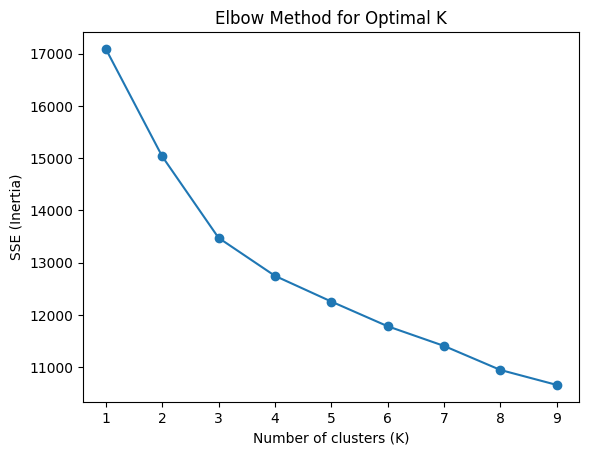

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def elbow_method(data, max_k=10):
    sse = []
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)  # Sum of squared distances to centroids

    plt.plot(range(1, max_k), sse, marker='o')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('SSE (Inertia)')
    plt.title('Elbow Method for Optimal K')
    plt.show()

elbow_method(embeddings)

In [28]:
embeddings

array([[-3.6051127e-01,  1.4834368e-01, -2.2565427e-01, ...,
        -3.9442936e-01, -3.5573095e-02, -1.1706799e-01],
       [-5.1779872e-01, -3.7631042e-02, -3.3742693e-01, ...,
        -5.1328117e-01,  1.6797313e-01, -1.3497963e-02],
       [-4.3615109e-01, -1.8950583e-01, -9.2869498e-02, ...,
        -3.7541831e-01,  1.8266907e-01,  5.0105564e-02],
       ...,
       [-4.5524466e-01, -2.7627915e-01, -1.8476267e-01, ...,
        -3.1071836e-01,  4.9253806e-02,  1.1663352e-02],
       [-6.8619311e-01, -1.7764609e-01, -2.5933757e-03, ...,
        -3.4398147e-01,  2.7000418e-01,  1.8269570e-01],
       [-1.9120184e-01, -2.5329420e-01, -1.2193709e-01, ...,
        -4.1485026e-01,  3.4326249e-01,  6.6241750e-04]], dtype=float32)

Plot saved as HTML at /content/drive/MyDrive/company_project/output_plot.html


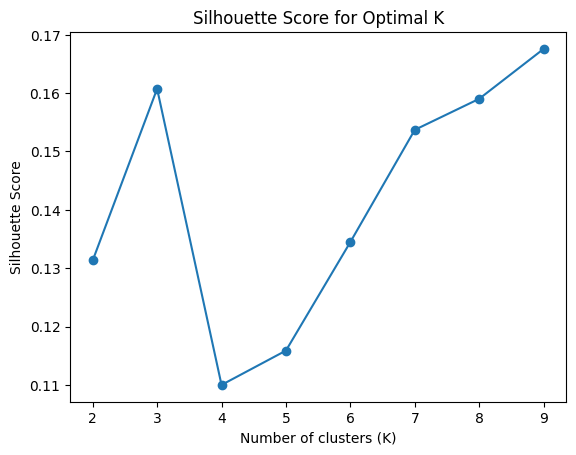

In [31]:
import matplotlib.pyplot as plt
import mpld3

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def silhouette_analysis(data, max_k=10, output_path="output_plot.html"):
    silhouette_scores = []
    for k in range(2, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)
        silhouette_avg = silhouette_score(data, labels)
        silhouette_scores.append(silhouette_avg)

    fig, ax = plt.subplots()
    ax.plot(range(2, max_k), silhouette_scores, marker='o')
    ax.set_xlabel('Number of clusters (K)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Silhouette Score for Optimal K')

    # Save the plot as an interactive HTML file
    mpld3.save_html(fig, output_path)
    print(f"Plot saved as HTML at {output_path}")

# Specify the absolute path where you want to save the HTML file
output_path = "/content/drive/MyDrive/company_project/output_plot.html"
silhouette_analysis(embeddings, output_path=output_path)


In [30]:
pwd

'/content'

In [3]:
!pip install mpld3 -qqq

!pip install bertopic -qqq
!pip install plotly -qqq
# !pip install scipy
!pip install scipy==1.11.4  -qqq
!pip install pandas -qqq
!pip install sentence_transformers -qqq
!pip install umap-learn -qqq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 35.5 MB/s eta 0:00:00


Interpreting the plot:
Peak at 3 clusters: The silhouette score peaks at K=3 with a score of around 0.16. This suggests that 3 clusters could be a reasonable choice because it's where the model has the highest silhouette score, indicating well-defined clustering.

Increasing silhouette score from K=6 onward: Starting from K=6, the silhouette score steadily increases, with the highest score for K=9. However, the silhouette scores for these higher values (e.g., K=8, K=9) do not increase as dramatically as the jump from K=2 to K=3.


Data Loaded and Preprocessed: (1268, 12)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embeddings generated: [[-3.6051109e-01  1.4834400e-01 -2.2565416e-01 ... -3.9442912e-01
  -3.5573103e-02 -1.1706823e-01]
 [-5.1779836e-01 -3.7630931e-02 -3.3742705e-01 ... -5.1328057e-01
   1.6797279e-01 -1.3497907e-02]
 [-4.3615073e-01 -1.8950579e-01 -9.2869304e-02 ... -3.7541795e-01
   1.8266918e-01  5.0105255e-02]
 ...
 [-4.5524430e-01 -2.7627915e-01 -1.8476273e-01 ... -3.1071830e-01
   4.9253255e-02  1.1663363e-02]
 [-6.8619305e-01 -1.7764594e-01 -2.5936025e-03 ... -3.4398142e-01
   2.7000391e-01  1.8269546e-01]
 [-1.9120148e-01 -2.5329408e-01 -1.2193677e-01 ... -4.1485021e-01
   3.4326172e-01  6.6220498e-04]]
eps: 0.2, min_samples: 5, Silhouette Score: 0.0619
eps: 0.2, min_samples: 10, Silhouette Score: 0.0116
eps: 0.2, min_samples: 15, Silhouette Score: -0.0210
eps: 0.3, min_samples: 5, Silhouette Score: 0.0619
eps: 0.3, min_samples: 10, Silhouette Score: 0.0116
eps: 0.3, min_samples: 15, Silhouette Score: -0.0210
eps: 0.4, min_samples: 5, Silhouette Score: 0.0619
eps: 0.4, min_s

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

Combined plot with DBSCAN saved as HTML at /content/drive/MyDrive/company_project/connect_combined_output_with_dbscan.html


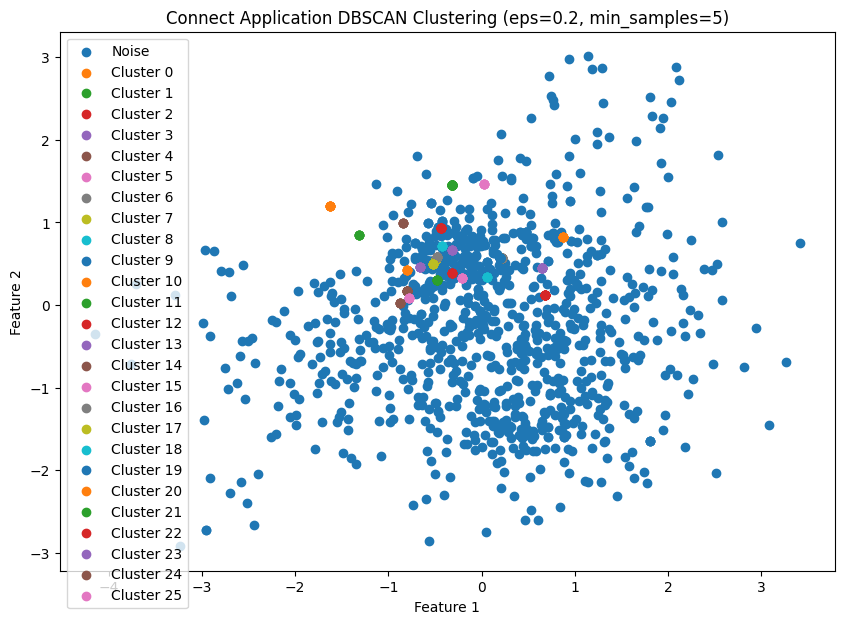

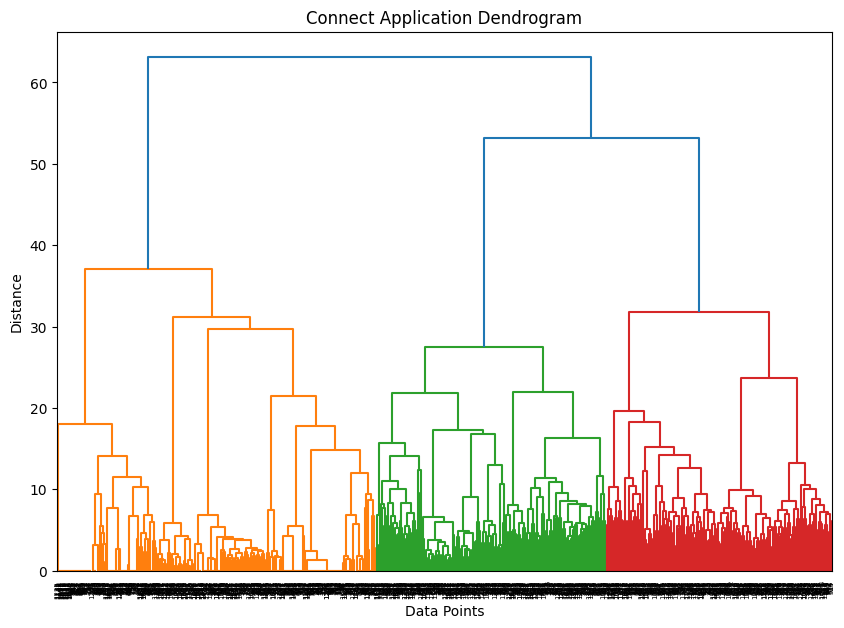

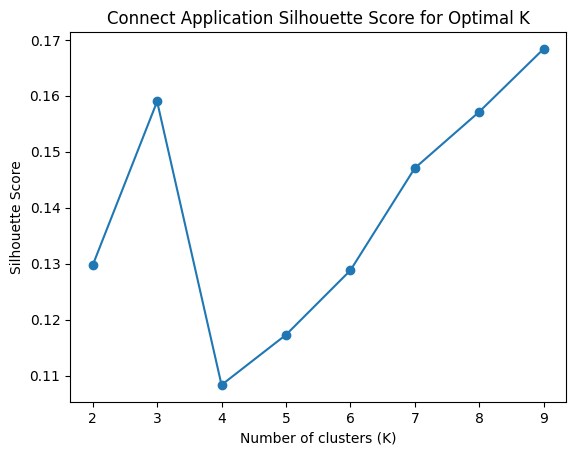

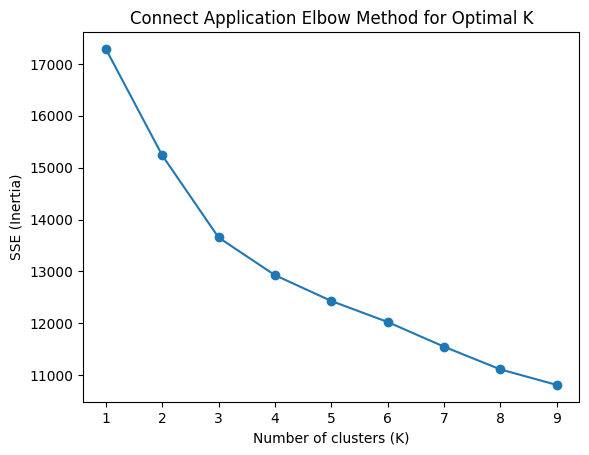

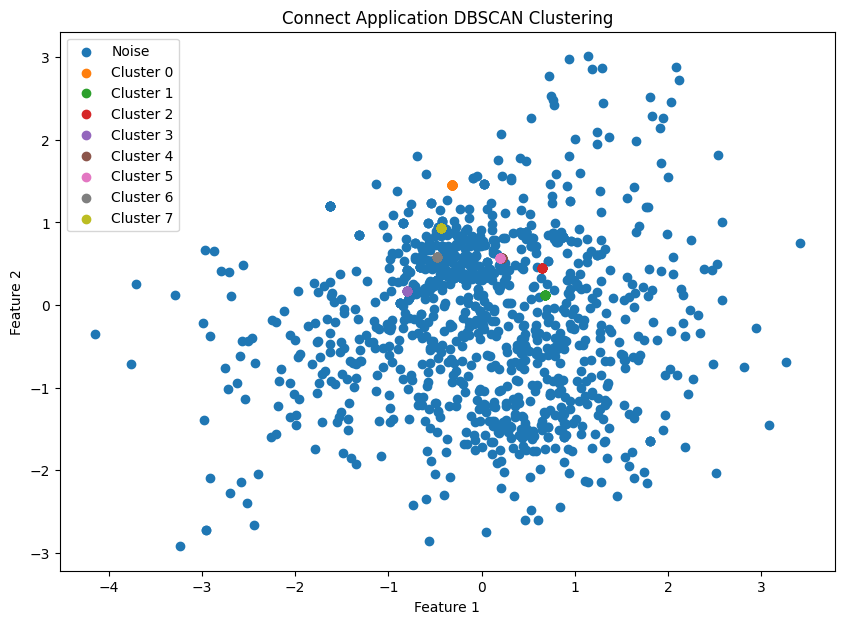

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import mpld3
from sentence_transformers import SentenceTransformer
import pandas as pd
from scipy.cluster.hierarchy import fcluster


from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np



import pandas as pd

class ConnectDataPreprocessor:
    def __init__(self, file_path):
        """
        Initialize the ConnectDataPreprocessor with the path to the CSV file.
        :param file_path: Path to the CSV file containing the data.
        """
        self.file_path = file_path

    def load_and_preprocess(self):
        """
        Load data from CSV and preprocess it by consolidating descriptions and cleaning null values.
        Returns the preprocessed DataFrame.
        """
        # Load data
        df = pd.read_csv(self.file_path)

        # Select relevant columns
        df = df[['incident_number', 'app_id', 'created_on', 'description',
                 'short_description', 'assignment_group', 'category', 'app_name',
                 'resolution_code', 'resolution_update', 'meta_tags']]

        # Combine descriptions
        df['consolidated_description'] = df['description'].fillna('') + ' ' + df['short_description'].fillna('')

        # Remove any rows with null consolidated descriptions
        df.dropna(subset=['consolidated_description'], inplace=True)

        return df

# Usage
if __name__ == "__main__":
    # Path to your data file


    file_path = "/content/drive/MyDrive/company_project/dummy_variable_data_public.csv"
    data_preprocessor = ConnectDataPreprocessor(file_path)

    # Load and preprocess data
    preprocessed_df = data_preprocessor.load_and_preprocess()
    print("Data Loaded and Preprocessed:", preprocessed_df.shape)


class ConnectTextEmbedding:
    def __init__(self, df, column_name, sentence_transformer_model='google-bert/bert-large-uncased'):

        # "dunzhang/stella_en_1.5B_v"

        """
        Initialize the TextEmbedding class to handle embedding tasks.
        :param df: DataFrame containing the text data.
        :param column_name: Name of the column containing text descriptions.
        :param sentence_transformer_model: Model to be used for sentence embeddings.
        """
        self.df = df
        self.column_name = column_name
        self.sentence_model = SentenceTransformer(sentence_transformer_model)

    def connect_encode_embeddings(self):
        """
        Encodes the descriptions into embeddings using the sentence model.
        """
        descriptions = self.df[self.column_name].tolist()
        return self.sentence_model.encode(descriptions, show_progress_bar=True)

# Usage
if __name__ == "__main__":
    # Load data
    # df = pd.read_csv("path_to_your_data.csv")  # Make sure to have the right path and data
    connect_text_embedding = ConnectTextEmbedding(preprocessed_df, "consolidated_description")

    # Generate embeddings
    connect_embeddings = connect_text_embedding.connect_encode_embeddings()

    # Now you can use 'embeddings' for any clustering or analysis tasks independently
    print("Embeddings generated:", connect_embeddings)

# Function to generate Dendrogram plot
def connect_plot_dendrogram(data, method='ward'):
    Z = linkage(data, method=method)
    fig, ax = plt.subplots(figsize=(10, 7))  # Create figure and axis
    dendrogram(Z, ax=ax)  # Create the dendrogram plot

    ax.set_title('Connect Application Dendrogram')
    ax.set_xlabel('Data Points')
    ax.set_ylabel('Distance')

    # Return the HTML for the plot
    return mpld3.fig_to_html(fig)

def connect_optimized_dendrogram(data, method='ward', metric='euclidean'):
    Z = linkage(data, method=method, metric=metric)
    fig, ax = plt.subplots(figsize=(10, 7))
    dendrogram(Z, ax=ax)
    ax.set_title(f'Connect Application Dendrogram - {method.capitalize()} Linkage')
    ax.set_xlabel('Data Points')
    ax.set_ylabel('Distance')
    return mpld3.fig_to_html(fig)


# Function to generate Silhouette Score plot
def connect_silhouette_analysis(data, max_k=10):
    connect_silhouette_scores = []
    for k in range(2, max_k):
        connect_kmeans = KMeans(n_clusters=k, random_state=42)
        connect_labels = connect_kmeans.fit_predict(data)
        connect_silhouette_avg = silhouette_score(data, connect_labels)
        connect_silhouette_scores.append(connect_silhouette_avg)

    fig, ax = plt.subplots()
    ax.plot(range(2, max_k), connect_silhouette_scores, marker='o')
    ax.set_xlabel('Number of clusters (K)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Connect Application Silhouette Score for Optimal K')

    # Return the HTML for the plot
    return mpld3.fig_to_html(fig)

from sklearn.preprocessing import StandardScaler

def connect_optimized_silhouette(data, max_k=10, random_state=42):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    silhouette_scores = []
    for k in range(2, max_k):
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        labels = kmeans.fit_predict(data_scaled)
        score = silhouette_score(data_scaled, labels)
        silhouette_scores.append(score)
    fig, ax = plt.subplots()
    ax.plot(range(2, max_k), silhouette_scores, marker='o')
    ax.set_title('Connect Application Optimized Silhouette Scores')
    return mpld3.fig_to_html(fig)



# Function to generate Elbow Method plot
def connect_elbow_method(data, max_k=10):
    connect_sse = []
    for k in range(1, max_k):
        connect_kmeans = KMeans(n_clusters=k, random_state=42)
        connect_kmeans.fit(data)
        connect_sse.append(connect_kmeans.inertia_)  # Sum of squared distances to centroids

    fig, ax = plt.subplots()
    ax.plot(range(1, max_k), connect_sse, marker='o')
    ax.set_xlabel('Number of clusters (K)')
    ax.set_ylabel('SSE (Inertia)')
    ax.set_title('Connect Application Elbow Method for Optimal K')

    # Return the HTML for the plot
    return mpld3.fig_to_html(fig)

def connect_optimized_elbow(data, max_k=10, random_state=42):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    sse = []
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        kmeans.fit(data_scaled)
        sse.append(kmeans.inertia_)
    fig, ax = plt.subplots()
    ax.plot(range(1, max_k), sse, marker='o')
    ax.set_title('Connect Application Optimized Elbow Method')
    return mpld3.fig_to_html(fig)



# Function to generate DBSCAN plot
def connect_dbscan_analysis(data, eps=0.5, min_samples=5):
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Apply DBSCAN algorithm
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(data_scaled)

    # Plot DBSCAN clustering results
    fig, ax = plt.subplots(figsize=(10, 7))

    # Plot the clustered points
    unique_labels = np.unique(labels)
    for label in unique_labels:
        label_mask = labels == label
        ax.scatter(data_scaled[label_mask, 0], data_scaled[label_mask, 1],
                   label=f'Cluster {label}' if label != -1 else 'Noise')

    # Adding title and labels
    ax.set_title('Connect Application DBSCAN Clustering')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc="best")

    # Return the HTML for the plot
    return mpld3.fig_to_html(fig)


# Function to fine-tune DBSCAN and return the best result
def connect_dbscan_analysis_grid_search_para_tunning(data, eps_values=[0.3, 0.5, 0.7, 1.0], min_samples_values=[5, 10, 15]):
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    best_silhouette = -1
    best_eps = None
    best_min_samples = None
    best_labels = None

    # Grid search over eps and min_samples values
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(data_scaled)

            # Ignore cases where DBSCAN assigns all points to noise (-1)
            if len(np.unique(labels)) > 1:
                score = silhouette_score(data_scaled, labels)
                print(f"eps: {eps}, min_samples: {min_samples}, Silhouette Score: {score:.4f}")

                if score > best_silhouette:
                    best_silhouette = score
                    best_eps = eps
                    best_min_samples = min_samples
                    best_labels = labels

    # Plot DBSCAN clustering results with the best parameters
    fig, ax = plt.subplots(figsize=(10, 7))

    # Plot the clustered points
    unique_labels = np.unique(best_labels)
    for label in unique_labels:
        label_mask = best_labels == label
        ax.scatter(data_scaled[label_mask, 0], data_scaled[label_mask, 1],
                   label=f'Cluster {label}' if label != -1 else 'Noise')

    # Adding title and labels
    ax.set_title(f'Connect Application DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc="best")

    # Return the HTML for the plot
    print(f'Best parameters: eps={best_eps}, min_samples={best_min_samples}, Silhouette Score={best_silhouette:.4f}')
    return mpld3.fig_to_html(fig)

# Example usage with grid search ranges
eps_values = [0.2, 0.3, 0.4, 0.5]
min_samples_values = [5, 10, 15]

# Best Value = eps = 0.2 and min_sample_values = 5

connect_dbscan_html_tunned = connect_dbscan_analysis_grid_search_para_tunning(connect_embeddings, eps_values=eps_values, min_samples_values=min_samples_values)

# Generate all three plots' HTML content
connect_dendrogram_html = connect_plot_dendrogram(connect_embeddings)
connect_silhouette_html = connect_silhouette_analysis(connect_embeddings, max_k=10)
connect_elbow_html = connect_elbow_method(connect_embeddings, max_k=10)

# Example usage
connect_dbscan_html = connect_dbscan_analysis(connect_embeddings, eps=0.3, min_samples=10)

class KMeansClustering:
    def __init__(self, n_clusters=3, random_state=42):
        """
        Initialize the K-Means clustering class.
        :param n_clusters: The number of clusters to use for K-Means.
        :param random_state: Seed for reproducibility.
        """
        self.n_clusters = n_clusters
        self.random_state = random_state

    def apply_kmeans(self, preprocessed_df, embeddings):
        """
        Apply K-Means clustering and add cluster labels to the dataframe.
        """
        kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        cluster_labels = kmeans.fit_predict(embeddings)

        # Add the K-Means cluster labels to the dataframe
        preprocessed_df['kmeans_cluster'] = cluster_labels
        return preprocessed_df


class HierarchicalClustering:
    def __init__(self, n_clusters=3, method='ward'):
        """
        Initialize the Hierarchical clustering class.
        :param n_clusters: The number of clusters to use.
        :param method: Linkage method ('ward', 'complete', 'average', etc.).
        """
        self.n_clusters = n_clusters
        self.method = method

    def apply_hierarchical_clustering(self, preprocessed_df, embeddings):
        """
        Apply Hierarchical clustering and add cluster labels to the dataframe.
        """
        Z = linkage(embeddings, method=self.method)

        # Generate cluster labels
        cluster_labels = fcluster(Z, self.n_clusters, criterion='maxclust')

        # Add the Hierarchical cluster labels to the dataframe
        preprocessed_df['hierarchical_cluster'] = cluster_labels
        return preprocessed_df


class DBSCANClustering:
    def __init__(self, eps=0.5, min_samples=5):
        """
        Initialize the DBSCAN clustering class.
        :param eps: The maximum distance between two samples for them to be considered as in the same neighborhood.
        :param min_samples: The minimum number of points required to form a dense region.
        """
        self.eps = eps
        self.min_samples = min_samples

    def apply_dbscan(self, preprocessed_df, embeddings):
        """
        Apply DBSCAN clustering and add cluster labels to the dataframe.
        """
        # Standardize the data
        scaler = StandardScaler()
        embeddings_scaled = scaler.fit_transform(embeddings)

        dbscan = DBSCAN(eps=self.eps, min_samples=self.min_samples)
        cluster_labels = dbscan.fit_predict(embeddings_scaled)

        # Add the DBSCAN cluster labels to the dataframe
        preprocessed_df['dbscan_cluster'] = cluster_labels
        return preprocessed_df


class OptimizedDBSCANClustering:

    def __init__(self, eps=0.2, min_samples=5):
        """
        Initialize the optimized DBSCAN clustering class.
        :param eps: The optimal eps value found through parameter tuning.
        :param min_samples: The optimal min_samples value found through parameter tuning.
        """
        self.eps = eps
        self.min_samples = min_samples

    def apply_optimized_dbscan(self, preprocessed_df, embeddings):
        """
        Apply optimized DBSCAN clustering and add cluster labels to the dataframe.
        """
        # Standardize the data
        scaler = StandardScaler()
        embeddings_scaled = scaler.fit_transform(embeddings)

        dbscan = DBSCAN(eps=self.eps, min_samples=self.min_samples)
        cluster_labels = dbscan.fit_predict(embeddings_scaled)

        # Add the optimized DBSCAN cluster labels to the dataframe
        preprocessed_df['optimized_dbscan_cluster'] = cluster_labels
        return preprocessed_df


# Example usage to apply all clustering methods
if __name__ == "__main__":
    # Load your preprocessed dataframe and embeddings
    # Assuming `preprocessed_df` and `connect_embeddings` have already been generated

    # Step 1: Apply K-Means Clustering
    kmeans_clusterer = KMeansClustering(n_clusters=3)
    preprocessed_df = kmeans_clusterer.apply_kmeans(preprocessed_df, connect_embeddings)

    # Step 2: Apply Hierarchical Clustering (Dendrogram)
    hierarchical_clusterer = HierarchicalClustering(n_clusters=3, method='ward')
    preprocessed_df = hierarchical_clusterer.apply_hierarchical_clustering(preprocessed_df, connect_embeddings)

    # Step 3: Apply DBSCAN Clustering
    # dbscan_clusterer = DBSCANClustering(eps=0.3, min_samples=10)
    # preprocessed_df = dbscan_clusterer.apply_dbscan(preprocessed_df, connect_embeddings)

    # Step 4: Apply Optimized DBSCAN Clustering
    optimized_dbscan_clusterer = OptimizedDBSCANClustering(eps=0.2, min_samples=5)
    preprocessed_df = optimized_dbscan_clusterer.apply_optimized_dbscan(preprocessed_df, connect_embeddings)

    # After applying all clustering approaches, print the resulting dataframe to check the labels
    # print(preprocessed_df.head())

    # Optionally, save the dataframe with clusters to a CSV file
    # preprocessed_df.to_csv("preprocessed_df_with_clusters.csv", index=False)


# Key observations text

connect_key_observations = """
<h2>Key Observations:</h2>
<p><strong>Dendrogram:</strong> There are three major branches at the top of the dendrogram (represented in different colors: orange, green, and red).
Cutting the dendrogram at this height would yield 3 clusters, which seems to align with the result from the silhouette analysis.
The large gap in height between the last two merges at around a distance of 60 suggests that 3 clusters is an appropriate choice here.
Cutting the dendrogram at this height would effectively separate the data into three distinct clusters.</p>

<p><strong>Silhouette Score:</strong> The silhouette score peaks at K=3, indicating that 3 clusters provide the most distinct separation among the clusters.
The score starts to drop after K=3, further confirming that 3 clusters is an optimal number for clustering.</p>

<p><strong>Elbow Method:</strong> The Elbow Method shows a clear elbow at K=3, indicating that the inertia (sum of squared distances) significantly decreases
until this point, and after K=3, the rate of decrease slows down. This supports the idea that 3 clusters are optimal for this dataset.</p>
"""

# Combine all four approaches into one HTML file with key observations
connect_output_path = "/content/drive/MyDrive/company_project/connect_combined_output_with_dbscan.html"
with open(connect_output_path, 'w') as f:
    f.write("<html><head><title>Connect Application Clustering Results</title></head><body>")
    f.write("<h1>Connect Application Dendrogram</h1>")
    f.write(connect_dendrogram_html)
    f.write("<h1>Connect Application Silhouette Score Plot</h1>")
    f.write(connect_silhouette_html)
    f.write("<h1>Connect Application Elbow Method Plot</h1>")
    f.write(connect_elbow_html)
    f.write("<h1>Connect Application DBSCAN Clustering</h1>")
    f.write(connect_dbscan_html)
    f.write(connect_key_observations)  # Add key observations at the end of the HTML file
    f.write("</body></html>")

print(f"Combined plot with DBSCAN saved as HTML at {connect_output_path}")

Key observations:
There are three major branches at the top of the dendrogram (represented in different colors: orange, green, and red). Cutting the dendrogram at this height would yield 3 clusters, which seems to align with the result from the silhouette analysis.

The large gap in height between the last two merges at around a distance of 60 suggests that 3 clusters is an appropriate choice here. Cutting the dendrogram at this height would effectively separate the data into three distinct clusters.

In [15]:
preprocessed_df.head()

,incident_number,app_id,created_on,description,short_description,assignment_group,category,app_name,resolution_code,resolution_update,meta_tags,consolidated_description,kmeans_cluster,hierarchical_cluster,optimized_dbscan_cluster
0,INC012569078,E0SV,2024-07-18T16:06:54.000,Fallout Receive-SBC-Start-Trigger-From-ESAP 45...,SO# 215115809 | Customer# WACKER SILICONE MAN...,NTS_E0SV_RVOIP_SUPPORT,Business Application Services,CONNECT,Service/Application Restarted,\r\nMentioned fallout is cleared.\r\nOrder is ...,E0SV 19032,Fallout Receive-SBC-Start-Trigger-From-ESAP 45...,1,2,-1
1,INC012555303,E0SV,2024-07-17T00:28:10.000,Description:tpalpe0sva001.verizon.com-NoRespon...,VSAD ID:E0SV;Description:tpalpe0sva001.verizon...,NTS_PS_VZINDIA,Business Application Services,CONNECT,Fixed by Automation,Good to Close,E0SV 19032,Description:tpalpe0sva001.verizon.com-NoRespon...,0,1,-1
2,INC012609983,E0SV,2024-07-24T11:48:21.000,Please clear/complete Check-For-Locations-Disc...,Please clear/complete Check-For-Locations-Disc...,NTS_E0SV_ESAPNET_SUPPORT,Business Application Services,CONNECT,Service/Application Restarted,Fallout cleared and order waiting for router d...,E0SV 19032,Please clear/complete Check-For-Locations-Disc...,2,3,-1
3,INC012674241,E0SV,2024-08-03T07:05:20.000,Ticket Automatically Created from OMi ---- \nO...,tdclpe0svd003-DISK SPACE: /apps/opt/postgres/b...,NTS_DBA_OPS_TECHOPS,Business Application Services,CONNECT,Resolved by Problem Management,PIT request raised for extending mountpoint,E0SV 19032,Ticket Automatically Created from OMi ---- \nO...,0,1,-1
4,INC012655659,E0SV,2024-07-31T14:02:58.000,WO-44165335 showing PC status IPSEC Provisioi...,WO-44165335 showing PC status IPSEC Provisioi...,NTS_E0SV_RVOIP_SUPPORT,Business Application Services,CONNECT,Database Updated/Data Scrub,WO 44165335 is now at WO_WAIT_FOR_IPSEC_INPUT...,E0SV 19032,WO-44165335 showing PC status IPSEC Provisioi...,2,3,-1


In [ ]:
import json
import psycopg2
import pandas as pd

class PostgresDatabase:
    def __init__(self, config_path):
        """
        Initialize the PostgresDatabase class by reading the JSON config file.
        :param config_path: Path to the JSON config file.
        """
        # Load the JSON config file
        with open(config_path, 'r') as file:
            self.config = json.load(file)

        # Create a connection string using the config data
        self.connection = None

    def connect(self):
        """
        Establish connection to the PostgreSQL database using the configuration provided.
        """
        try:
            self.connection = psycopg2.connect(
                dbname=self.config['dbname'],
                user=self.config['user'],
                password=self.config['password'],
                host=self.config['host'],
                port=self.config['port']
            )
            print("Connection to PostgreSQL established successfully.")
        except Exception as e:
            print(f"Error connecting to PostgreSQL: {e}")

    def close_connection(self):
        """
        Close the connection to the database.
        """
        if self.connection:
            self.connection.close()
            print("PostgreSQL connection closed.")

    def read_data(self, query=None):
        """
        Read data from PostgreSQL database and return it as a DataFrame.
        :param query: SQL query to execute. If not provided, will fetch all data from the specified table.
        :return: Pandas DataFrame containing the result set.
        """
        if query is None:
            query = f"SELECT * FROM {self.config['schema']}.{self.config['table']}"

        try:
            df = pd.read_sql(query, self.connection)
            print("Data fetched successfully.")
            return df
        except Exception as e:
            print(f"Error fetching data: {e}")
            return None

    def write_data(self, dataframe, table_name):
        """
        Write data from a Pandas DataFrame to a PostgreSQL table.
        :param dataframe: The DataFrame containing the data to write.
        :param table_name: The name of the table where data will be written.
        """
        try:
            # Establish a cursor
            cursor = self.connection.cursor()
            # Insert data row by row (can be optimized for batch inserts)
            for row in dataframe.itertuples(index=False):
                columns = ', '.join(dataframe.columns)
                values = ', '.join([f"'{str(value)}'" for value in row])
                insert_query = f"INSERT INTO {self.config['schema']}.{table_name} ({columns}) VALUES ({values})"
                cursor.execute(insert_query)

            # Commit the transaction
            self.connection.commit()
            cursor.close()
            print("Data written to PostgreSQL successfully.")
        except Exception as e:
            print(f"Error writing data to PostgreSQL: {e}")


# Example usage
if __name__ == "__main__":
    # Path to the JSON config file
    config_path = "/path/to/vz_postgrace_credential_reading.json"  # Update this path

    # Initialize the PostgresDatabase class
    db = PostgresDatabase(config_path)

    # Connect to the PostgreSQL database
    db.connect()

    # Example: Read data from the database
    query = "SELECT * FROM opsdb.ays_intake_view_1 LIMIT 5"
    data = db.read_data(query)
    print(data.head())

    # Example: Write data (assuming you have a DataFrame called df_to_write)
    # db.write_data(df_to_write, table_name='your_table')

    # Close the connection
    db.close_connection()
